In [94]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [98]:
class PINN(nn.Module):

    def __init__(self, layers):
        super().__init__()

        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()

        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self,x):

        for i in range(len(self.layers)-1):
            x = self.activation(self.layers[i](x))

        x = self.layers[-1](x)

        return x

layers = [1,50,50,50,1]
model = PINN(layers)

In [99]:
def sample_collocation(n_points):

    x = torch.rand(n_points,1)

    x.requires_grad = True

    return x

In [100]:
def pde_residual(model,x):

    u = model(x)

    du_dx = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2u_dx2 = torch.autograd.grad(
        du_dx, x,
        grad_outputs=torch.ones_like(du_dx),
        create_graph=True
    )[0]

    forcing = -np.pi**2 * torch.sin(np.pi*x)

    residual = d2u_dx2 - forcing

    return residual

In [101]:
x_bc = torch.tensor([[0.0],[1.0]])
u_bc = torch.tensor([[0.0],[0.0]])

In [102]:
def boundary_loss(model):

    pred = model(x_bc)

    return torch.mean((pred-u_bc)**2)

In [103]:
def physics_loss(model,x):

    residual = pde_residual(model,x)

    return torch.mean(residual**2)

In [104]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

epochs = 5000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    x_f = sample_collocation(100)

    p_loss = physics_loss(model,x_f)
    b_loss = boundary_loss(model)

    loss = p_loss + b_loss

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch%500==0:
        print(epoch,loss.item())

0 47.282100677490234
500 0.0040326230227947235
1000 0.0023605094756931067
1500 0.002637279685586691
2000 0.0012646903051063418
2500 0.0012501105666160583
3000 0.000580234220251441
3500 8.523469296051189e-05
4000 9.487011993769556e-05
4500 0.0001422919740434736


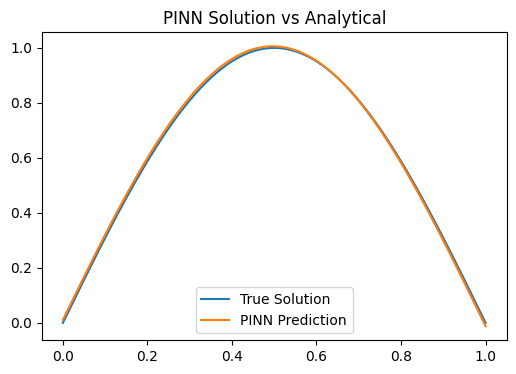

In [109]:
x_test = torch.linspace(0,1,200).view(-1,1)

with torch.no_grad():
    pred = model(x_test)

true = torch.sin(np.pi*x_test)
plt.figure(figsize=(6,4))
plt.plot(x_test,true,label="True Solution")
plt.plot(x_test,pred,label="PINN Prediction")
plt.legend()
plt.title("PINN Solution vs Analytical")
plt.show()

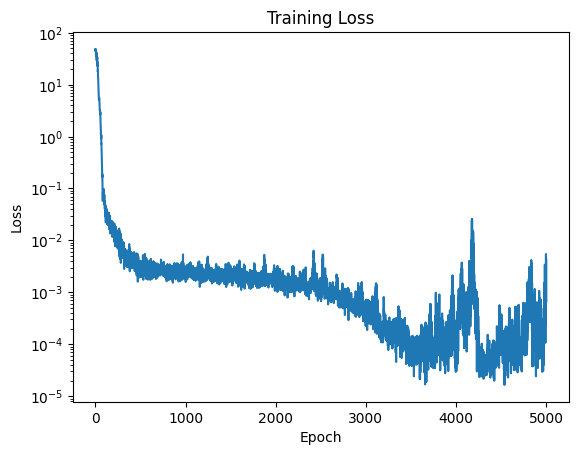

In [110]:
plt.figure()
plt.plot(loss_history)
plt.yscale("log")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()